<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-4/BreastCancer_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV

##Task 1: Data Preparation


In [35]:
from sklearn.datasets import load_breast_cancer
# Loaded the dataset
bc = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(bc.data, columns=bc.feature_names)

display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [36]:
df.info()

print("Dataset shape:",df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [37]:
df.isnull().sum()


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


### Data Quality Assessment

The dataset was checked for missing values and duplicate records. No missing values or duplicates were found, indicating that the dataset is clean and ready for preprocessing.

In [38]:

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

# Convert the scaled data back to a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Feature Scaling

The features were standardized using the StandardScaler, which transforms each feature to have a mean of 0 and a standard deviation of 1. This step is essential for KNN because distance calculations are sensitive to differences in feature scales.

##Task 2: Train-Test Split Analysis


In [39]:
# Features (already standardized)
X = df_scaled

# Target labels
y = pd.Series(bc.target, name="target")

In [40]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

### Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio. The training set was used to train the KNN classifier, while the testing set was reserved for evaluating its performance on unseen data.

In [41]:
import math

k_80 = int(math.sqrt(len(X_train_80)))
k_70 = int(math.sqrt(len(X_train_70)))
k_90 = int(math.sqrt(len(X_train_90)))

# Make K odd
if k_80 % 2 == 0:
    k_80 += 1
if k_70 % 2 == 0:
    k_70 += 1
if k_90 % 2 == 0:
    k_90 += 1

print(k_70, k_80, k_90)

19 21 23


In [42]:
# 70:30
knn_70 = KNeighborsClassifier(n_neighbors=k_70)
knn_70.fit(X_train_70, y_train_70)
y_pred_70 = knn_70.predict(X_test_70)
accuracy_70 = accuracy_score(y_test_70, y_pred_70)

# 80:20
knn_80 = KNeighborsClassifier(n_neighbors=k_80)
knn_80.fit(X_train_80, y_train_80)
y_pred_80 = knn_80.predict(X_test_80)
accuracy_80 = accuracy_score(y_test_80, y_pred_80)

# 90:10
knn_90 = KNeighborsClassifier(n_neighbors=k_90)
knn_90.fit(X_train_90, y_train_90)
y_pred_90 = knn_90.predict(X_test_90)
accuracy_90 = accuracy_score(y_test_90, y_pred_90)

In [43]:
# Create a comparison table
comparison_df = pd.DataFrame({
    "Split": ["70:30", "80:20", "90:10"],
    "Training Samples": [len(X_train_70), len(X_train_80), len(X_train_90)],
    "Testing Samples": [len(X_test_70), len(X_test_80), len(X_test_90)],
    "K Value": [k_70, k_80, k_90],
    "Accuracy": [accuracy_70, accuracy_80, accuracy_90]
})

# Format accuracy as percentage
comparison_df["Accuracy"] = comparison_df["Accuracy"].apply(lambda x: f"{x:.2%}")

display(comparison_df)

,Split,Training Samples,Testing Samples,K Value,Accuracy
0,70:30,398,171,19,94.74%
1,80:20,455,114,21,95.61%
2,90:10,512,57,23,98.25%


##Task 3: KNN Model with Heuristic K Selection


###3.1 Heuristic Method for K Selection

In [44]:
import math

# Compute heuristic K
k = int(math.sqrt(len(X_train_80)))

# Make K odd
if k % 2 == 0:
    k += 1

print(f"Heuristic K = {k}")

Heuristic K = 21


In [45]:
knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train_80, y_train_80)

y_pred = knn.predict(X_test_80)

accuracy = accuracy_score(y_test_80, y_pred)

print(f"Accuracy (K={k}): {accuracy:.4f}")

Accuracy (K=21): 0.9561


### Heuristic K Selection

An initial value of K was determined using the √n heuristic, where n is the number of training samples. This provides a reasonable starting point for selecting the optimal number of nearest neighbors.

### 3.2 Model Training


In [46]:
heuristic_k = 21

k_values = [heuristic_k + i for i in [-4, -2, 0, 2, 4]]

print("K values tested:", k_values)

accuracies = []

for current_k in k_values:
    knn = KNeighborsClassifier(n_neighbors=current_k)
    knn.fit(X_train_80, y_train_80)

    y_pred = knn.predict(X_test_80)

    acc = accuracy_score(y_test_80, y_pred)
    accuracies.append(acc)

    print(f"K = {current_k:2d} | Accuracy = {acc:.4f}")

K values tested: [17, 19, 21, 23, 25]
K = 17 | Accuracy = 0.9737
K = 19 | Accuracy = 0.9737
K = 21 | Accuracy = 0.9561
K = 23 | Accuracy = 0.9649
K = 25 | Accuracy = 0.9649


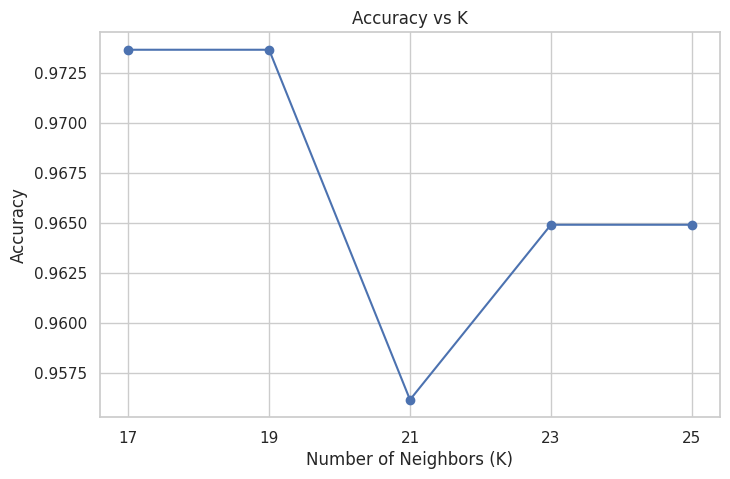

In [47]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o')

plt.title("Accuracy vs K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [48]:
best_index = np.argmax(accuracies)

best_k = k_values[best_index]
best_accuracy = accuracies[best_index]

print(f"Best K: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best K: 17
Best Accuracy: 0.9737


### Effect of K on Model Performance

The model was evaluated using several K values around the heuristic value. The results show that the choice of K directly affects classification accuracy. Smaller K values may overfit the data, while larger K values may underfit. The K value with the highest accuracy was selected for further evaluation.

### 3. 3 Distance Matrix and Decision Boundary Mapping


Euclidean Distance (L2 Distance)

Definition:
Euclidean distance measures the straight-line distance between two points in a multi-dimensional space. It is the default distance metric used in KNN.


When it is suitable:

Continuous numerical data.
Features are on similar scales (after feature scaling using StandardScaler).
Low to moderate dimensional datasets.

Manhattan Distance (L1 Distance)

Definition:
Manhattan distance measures the sum of the absolute differences between corresponding feature values. It is also known as the City Block Distance because it resembles the distance traveled along city streets laid out in a grid.

When it is suitable:

High-dimensional datasets.
Datasets containing outliers.
Problems where movement is naturally constrained to horizontal and vertical paths (grid-like movement).

The Breast Cancer dataset contains 30 features. Since a decision boundary can only be visualized in two dimensions, PCA was applied to reduce the feature space to two principal components for visualization purposes. The full-dimensional data was used for model training and evaluation in the other tasks.

In [49]:
from sklearn.decomposition import PCA

# Reduce the feature space from 30 dimensions to 2
pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_80)
X_test_pca = pca.transform(X_test_80)

print("Original shape:", X_train_80.shape)
print("Reduced shape:", X_train_pca.shape)

Original shape: (455, 30)
Reduced shape: (455, 2)


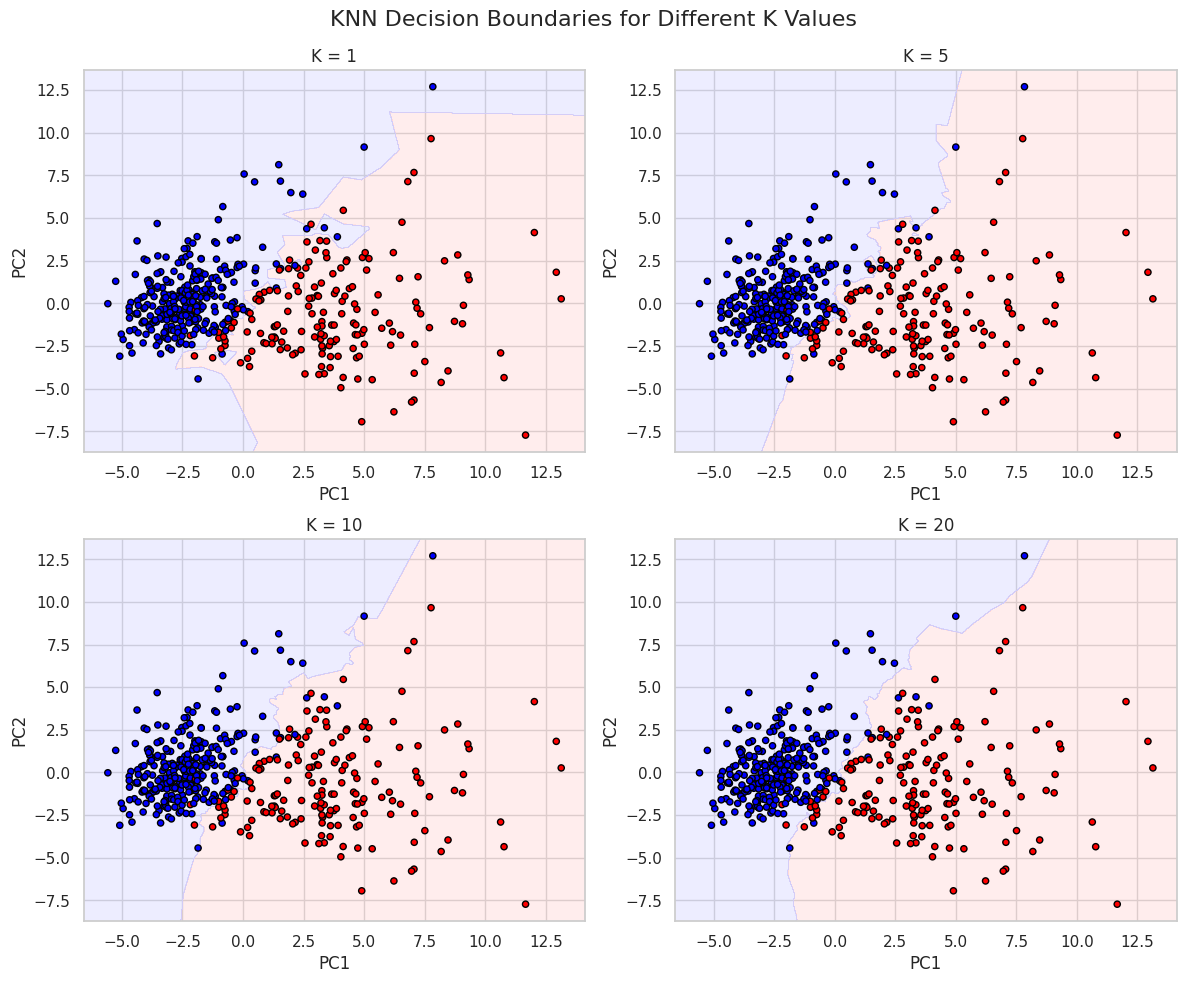

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

k_values = [1, 5, 10, 20]

for ax, k in zip(axes, k_values):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train_80)

    h = 0.02
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.35,
        cmap=ListedColormap(["#FFCCCC", "#CCCCFF"])
    )

    ax.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=y_train_80,
        cmap=ListedColormap(["red", "blue"]),
        edgecolors="black",
        s=20
    )

    ax.set_title(f"K = {k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True)

# Tight layout
plt.tight_layout(pad=1.0)

# Optional overall title
fig.suptitle("KNN Decision Boundaries for Different K Values", fontsize=16)
plt.subplots_adjust(top=0.92)

plt.show()

### Decision Boundary Analysis

The decision boundaries become smoother as the value of K increases. Smaller K values produce complex boundaries that closely follow the training data, whereas larger K values create smoother boundaries that generalize better but may overlook local patterns.


As K increases, the decision boundary becomes progressively smoother. The goal is to find a K that is smooth enough to generalize well but flexible enough to capture the true class boundary — this is the bias-variance trade-off.

## Task 4


In [51]:
from sklearn.model_selection import cross_val_score

k_values = list(range(best_k - 5, best_k + 6, 2))
cv_mean_accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_80,
        y_train_80,
        cv=5,
        scoring='accuracy'
    )

    cv_mean_accuracy.append(scores.mean())

    print(f"K = {k:2d} | Mean CV Accuracy = {scores.mean():.4f}")


K = 12 | Mean CV Accuracy = 0.9670
K = 14 | Mean CV Accuracy = 0.9648
K = 16 | Mean CV Accuracy = 0.9604
K = 18 | Mean CV Accuracy = 0.9582
K = 20 | Mean CV Accuracy = 0.9582
K = 22 | Mean CV Accuracy = 0.9560


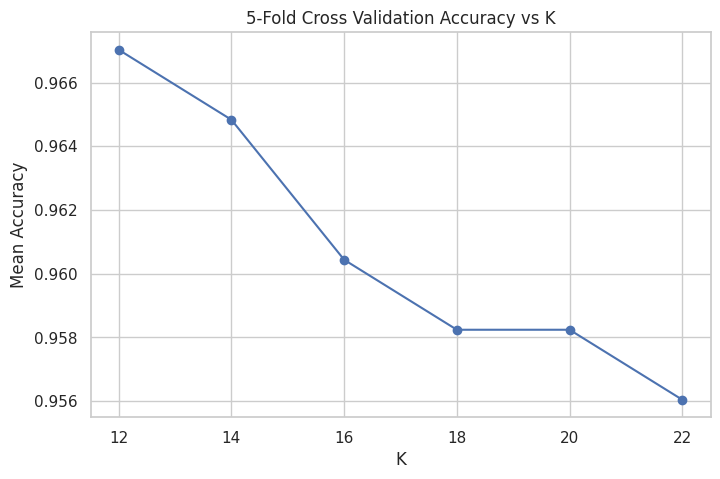

In [52]:
plt.figure(figsize=(8,5))

plt.plot(k_values, cv_mean_accuracy, marker='o')

plt.title("5-Fold Cross Validation Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Mean Accuracy")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [56]:
best_cv_index = np.argmax(cv_mean_accuracy)

best_k = k_values[best_cv_index]
best_cv_accuracy = cv_mean_accuracy[best_cv_index]

print(f"Best K from Cross Validation: {best_k}")
print(f"Mean CV Accuracy: {best_cv_accuracy:.4f}")

Best K from Cross Validation: 12
Mean CV Accuracy: 0.9670


### Cross-Validation Results

Five-fold cross-validation was performed to evaluate the model across multiple data splits. The mean accuracy provides a more reliable estimate of model performance than a single train-test split and helps in selecting the most appropriate K value.

## Task 5

In [57]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_80, y_train_80)

# Predictions
y_pred = final_knn.predict(X_test_80)

# Probabilities for ROC Curve
y_prob = final_knn.predict_proba(X_test_80)[:, 1]

In [58]:
accuracy = accuracy_score(y_test_80, y_pred)
precision = precision_score(y_test_80, y_pred)
recall = recall_score(y_test_80, y_pred)
f1 = f1_score(y_test_80, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9737
Precision: 0.9600
Recall   : 1.0000
F1 Score : 0.9796


### Classification Metrics

The evaluation metrics indicate that the KNN classifier performs well in identifying benign and malignant cases. While accuracy provides overall performance, precision, recall, and F1-score offer a more comprehensive assessment of the classifier's effectiveness.

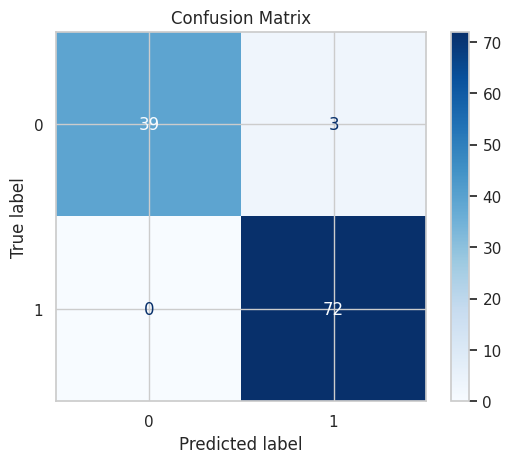

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_80, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Analysis

The confusion matrix summarizes the model's predictions by showing the number of correct and incorrect classifications. A high number of true positives and true negatives, along with few false predictions, indicates good classification performance.

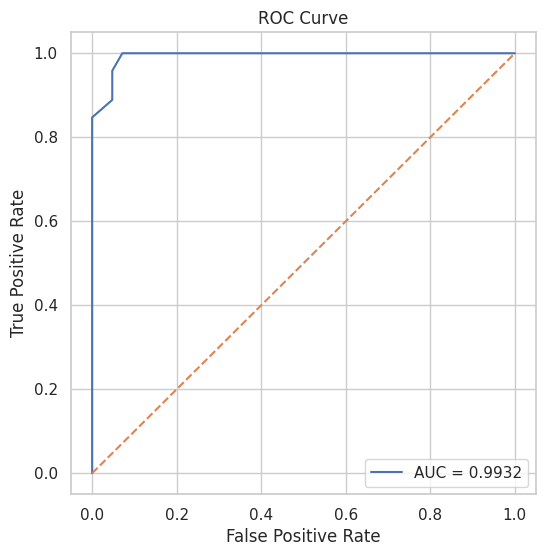

AUC: 0.9932


In [61]:
fpr, tpr, thresholds = roc_curve(y_test_80, y_prob)
auc = roc_auc_score(y_test_80, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print(f"AUC: {auc:.4f}")

### ROC Curve and AUC

The ROC curve illustrates the trade-off between the True Positive Rate and the False Positive Rate at different classification thresholds. A higher AUC score indicates that the classifier has a strong ability to distinguish between benign and malignant cases.

### Comparison of Regression and Classification Evaluation Metrics

Regression and classification models are evaluated differently because they solve different types of problems. Regression predicts continuous numerical values, so its evaluation focuses on measuring how close the predicted values are to the actual values. Classification predicts discrete class labels, so its evaluation focuses on how accurately the model assigns observations to the correct class.

###Error-based Evaluation vs Decision-based Evaluation

Regression uses error-based evaluation, where the difference between the predicted and actual values is calculated as an error. Metrics such as MAE, MSE, and RMSE measure the magnitude of these errors, while the R² score indicates how well the model explains the variation in the data.

Classification uses decision-based evaluation, where predictions are treated as correct or incorrect class assignments. Metrics such as Accuracy, Precision, Recall, F1 Score, and the Confusion Matrix evaluate how well the model distinguishes between different classes rather than measuring numerical error.

###R² Score vs Accuracy

The R² Score measures how well a regression model explains the variability in the target variable. A higher R² value indicates that the model captures more of the underlying relationship in the data.

Accuracy measures the proportion of correctly classified instances in a classification problem. Unlike R², it does not measure prediction error but simply checks whether the predicted class matches the actual class.

RMSE vs F1 Score

RMSE (Root Mean Squared Error) measures the average prediction error in regression while giving greater importance to larger errors because the errors are squared before averaging. A lower RMSE indicates better predictive performance.

F1 Score is the harmonic mean of Precision and Recall in classification. It provides a balanced measure of performance, especially when the dataset is imbalanced, by considering both false positives and false negatives.

###MAE vs Confusion Matrix

MAE (Mean Absolute Error) calculates the average absolute difference between predicted and actual values in regression. It provides a straightforward measure of the average prediction error without giving extra weight to large errors.

A Confusion Matrix summarizes the performance of a classification model by showing the number of true positives, true negatives, false positives, and false negatives. Instead of measuring numerical error, it provides detailed insight into the types of classification mistakes made by the model.



###Differences in Evaluation Logic

For continuous prediction tasks (Regression), the objective is to minimize the difference between predicted and actual numerical values. Therefore, evaluation metrics focus on measuring the magnitude of prediction errors and the model's ability to explain the data.

For classification tasks, the objective is to correctly assign each observation to a predefined class. Evaluation metrics focus on the correctness of these decisions, the balance between different types of errors, and the model's ability to distinguish between classes effectively.

## Inference

How regression metrics measure prediction error magnitude
- Regression metrics like MSE, RMSE and MAE are all derived from the error of the prediction.

How classification metrics measure decision correctness
- Classification metrics have no quantifiable measure of correctness as the predition's accuracy is always boolean. Either true or false.

Why is accuracy insufficient in medical diagnosis
- Accuracy in models is subjective to the dataset. In medical context, the accuracy alone is not sufficient. In a dataset with 100 people in which 5 are sick, the model predicts all as healthy. The model's accuracy is 95% but the model has not been trained to identify sick people due to its class imbalance.

Why recall and ROC-AUC are more relevant in healthcare
- The ROC-AUC curve is a better metric for classification models in healthcare as it provides a more deeper insight into the model across all thresholds. The ROC-AUC shows the models accuracy in both True and False predictions.

Overall comparison between regression and classification evaluation frameworks
- Regression model's metrics focus on the error levels. Whereas, classification model's metrics use the prediction's correctness.


##Task 7

### Why is KNN called a lazy learning algorithm?

KNN is called a *lazy learning algorithm* because it does not build a model during training. Instead, it stores the training data and performs all computations during prediction by finding the nearest neighbors. This results in fast training but slower prediction.



### Why is feature scaling required in KNN?

KNN uses distance calculations to classify data. If features have different scales, larger-valued features dominate the distance measure. Feature scaling ensures all features contribute equally, improving prediction accuracy.


### Explain heuristic K selection using the √n rule.

A common heuristic is to choose **K = √n**, where *n* is the number of training samples. This provides a good starting point that balances overfitting and underfitting. For binary classification, K is usually chosen as an odd number to reduce ties.



### Why is cross-validation more reliable than a single train-test split?

A single train-test split depends on one partition of the data, which may not represent overall performance. Cross-validation evaluates the model on multiple splits, providing a more reliable and stable estimate of its performance.

### How does K affect the bias-variance trade-off?

A **small K** creates a complex model with **low bias and high variance**, which may overfit the data. A **large K** creates a simpler model with **high bias and low variance**, which may underfit the data.



### Why is recall more important than accuracy in cancer prediction?

In cancer prediction, missing a patient who has cancer (false negative) is more serious than incorrectly predicting cancer (false positive). Therefore, **recall** is more important because it measures how many actual cancer cases are correctly identified.



### What is the limitation of very large K values?

A very large K considers too many neighbors, making the decision boundary overly smooth. This can cause **underfitting**, where the model ignores important patterns and tends to predict the majority class.


### **Conclusion**

The optimal K value was determined using the **√n heuristic** and validated through performance evaluation and cross-validation. The **80:20 train-test split** provided a good balance between training and testing, with only minor performance differences observed across the other split ratios.

The final KNN model achieved strong performance based on **Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC**, demonstrating effective classification of breast cancer cases.

Compared to **Lab 3**, which used error-based metrics (MAE, MSE, RMSE, and R²) for regression, this lab used decision-based metrics to evaluate classification performance. Overall, the experiment highlighted the importance of feature scaling, K selection, and cross-validation in building a reliable KNN classifier.
